### Importing Python libraries

In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix

# EDA (Explanatory Data Analysis)

## Basic EDA Pipeline

*	Explore the dataset.
*	Understand its structure and contents.
*	Discover patterns, relationships and anomalies.
*	Prepare it for further modeling or decision-making.



# Stages of EDA
### Common EDA Techniques:
* Descriptive Analysis
*	Correlation Analysis
*	Check imbalance in data


In [102]:
df = pd.read_csv("3.csv")
df

,Age,Income,Gender,Marital_Status,Credit_Score,Num_Purchases,Membership_Years,Device_Used,Churn
0,56.0,70201.189680,Female,Married,687.761776,9,12,Desktop,0
1,69.0,51901.897395,Male,Single,712.617115,3,14,Tablet,0
2,46.0,38605.409293,Male,Married,782.299643,5,8,Mobile,0
3,32.0,49949.736955,Female,Single,697.749518,7,1,Tablet,0
4,NaN,48965.290095,Other,Married,663.155216,4,4,Desktop,1
...,...,...,...,...,...,...,...,...,...
1495,40.0,38575.311408,Male,Single,717.997517,3,9,Mobile,0
1496,54.0,47273.370862,Other,Single,678.621530,4,2,Desktop,1
1497,28.0,52600.121356,Other,Divorced,611.316046,2,3,Desktop,0
1498,23.0,63187.644522,Female,Divorced,690.256745,5,7,Tablet,1


In [103]:
df.head()

,Age,Income,Gender,Marital_Status,Credit_Score,Num_Purchases,Membership_Years,Device_Used,Churn
0,56.0,70201.189680,Female,Married,687.761776,9,12,Desktop,0
1,69.0,51901.897395,Male,Single,712.617115,3,14,Tablet,0
2,46.0,38605.409293,Male,Married,782.299643,5,8,Mobile,0
3,32.0,49949.736955,Female,Single,697.749518,7,1,Tablet,0
4,NaN,48965.290095,Other,Married,663.155216,4,4,Desktop,1


In [104]:
df.isna().sum()

,0
Age,75
Income,75
Gender,75
Marital_Status,0
Credit_Score,75
Num_Purchases,0
Membership_Years,0
Device_Used,0
Churn,0


In [105]:
print(f"Shape of the dataset is {df.shape}. This dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")

Shape of the dataset is (1500, 9). This dataset contains 1500 rows and 9 columns.


### Features

In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1425 non-null   float64
 1   Income            1425 non-null   float64
 2   Gender            1425 non-null   object 
 3   Marital_Status    1500 non-null   object 
 4   Credit_Score      1425 non-null   float64
 5   Num_Purchases     1500 non-null   int64  
 6   Membership_Years  1500 non-null   int64  
 7   Device_Used       1500 non-null   object 
 8   Churn             1500 non-null   int64  
dtypes: float64(3), int64(3), object(3)
memory usage: 105.6+ KB


### Splitting Categorical and Numerical features

In [107]:
numerical_data = df.select_dtypes(include='number')

print(f"this dataset has {numerical_data.shape[1]} numerical features:")
numerical_features = numerical_data.columns.tolist()
print(numerical_features)

this dataset has 6 numerical features:
['Age', 'Income', 'Credit_Score', 'Num_Purchases', 'Membership_Years', 'Churn']


In [108]:
categorical_data = df.select_dtypes(include='object')

print(f"this dataset has {categorical_data.shape[1]} categorical features:")
categorical_features = categorical_data.columns.tolist()
print(categorical_features)

this dataset has 3 categorical features:
['Gender', 'Marital_Status', 'Device_Used']


### Descriptive Analysis

#### In descriptive Analysis we analysis each variable separately to get inference about the feature.

In [109]:
# numerical_data
numerical_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1425.0,43.750175,15.026126,18.000000,31.000000,44.000000,56.000000,69.000000
Income,1425.0,50446.150664,15320.475325,-826.421240,40557.251779,50671.503006,60994.627689,98819.709397
Credit_Score,1425.0,648.786794,69.583710,390.384237,601.996211,650.015506,694.954684,906.039126
Num_Purchases,1500.0,5.078667,2.260653,0.000000,3.000000,5.000000,6.000000,16.000000
Membership_Years,1500.0,7.388667,3.974603,1.000000,4.000000,7.000000,11.000000,14.000000
Churn,1500.0,0.495333,0.500145,0.000000,0.000000,0.000000,1.000000,1.000000


In [110]:
# categorical_data
categorical_data.describe().T

,count,unique,top,freq
Gender,1425,3,Other,486
Marital_Status,1500,3,Divorced,522
Device_Used,1500,3,Desktop,528


In [111]:
# variance of numerical_data
numerical_data.var()

,0
Age,2.257845e+02
Income,2.347170e+08
Credit_Score,4.841893e+03
Num_Purchases,5.110552e+00
Membership_Years,1.579747e+01
Churn,2.501450e-01


## What is Skewness?
### Skewness measures the asymmetry of the distribution of a dataset.

Skewness = 0 → Perfectly symmetrical (e.g., normal distribution)

Skewness < 0 → Left-skewed (long tail on the left)

Skewness > 0 → Right-skewed (long tail on the right)

## Skewness Value Interpretation

~ 0 Symmetrical (normal-ish)

0 to ±0.5 Fairly symmetrical

±0.5 to ±1 Moderately skewed

greater than ±1 Highly skewed

In [112]:
# Skewness in numerical_data
numerical_data.skew()

,0
Age,-0.041694
Income,-0.029135
Credit_Score,-0.058151
Num_Purchases,0.485069
Membership_Years,0.016571
Churn,0.018686


### skewness value interpreteion

<ul>
  <li>
    <strong>Age</strong> (Skewness: <em>-0.041694</em>)
    <ul>
      <li><strong>Distribution:</strong> Almost normal</li>
      <li><strong>Meaning:</strong> Age values are nicely balanced</li>
    </ul>
  </li>

  <li>
    <strong>Income</strong> (Skewness: <em>-0.029135</em>)
    <ul>
      <li><strong>Distribution:</strong> Almost normal</li>
      <li><strong>Meaning:</strong> Income data is also balanced</li>
    </ul>
  </li>

  <li>
    <strong>Credit_Score</strong> (Skewness: <em>-0.058151</em>)
    <ul>
      <li><strong>Distribution:</strong> Almost normal</li>
      <li><strong>Meaning:</strong> Credit scores are evenly spread</li>
    </ul>
  </li>

  <li>
    <strong>Num_Purchases</strong> (Skewness: <em>0.485069</em>)
    <ul>
      <li><strong>Distribution:</strong> Slightly / moderately right-skewed</li>
      <li><strong>Meaning:</strong> Some customers made many purchases, but most made fewer</li>
    </ul>
  </li>

  <li>
    <strong>Membership_Years</strong> (Skewness: <em>0.016571</em>)
    <ul>
      <li><strong>Distribution:</strong> Almost normal</li>
      <li><strong>Meaning:</strong> Membership duration is evenly distributed</li>
    </ul>
  </li>

  <li>
    <strong>Churn</strong> (Skewness: <em>0.016571</em>)
    <ul>
      <li><strong>Distribution:</strong> Almost normal</li>
      <li><strong>Meaning:</strong> Churn values are balanced</li>
    </ul>
  </li>
</ul>


# Histogram and Box Plots

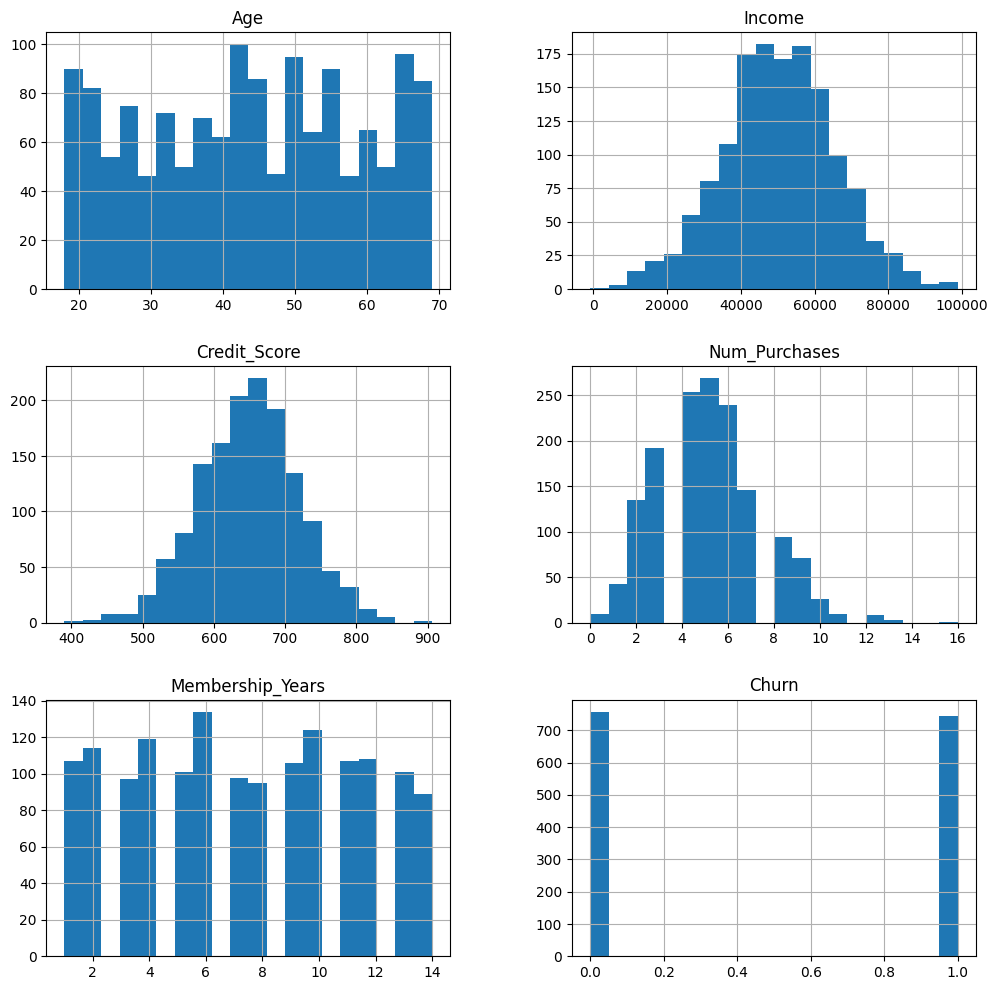

In [113]:
numerical_data.hist(figsize=(12,12),bins=20)
plt.show()

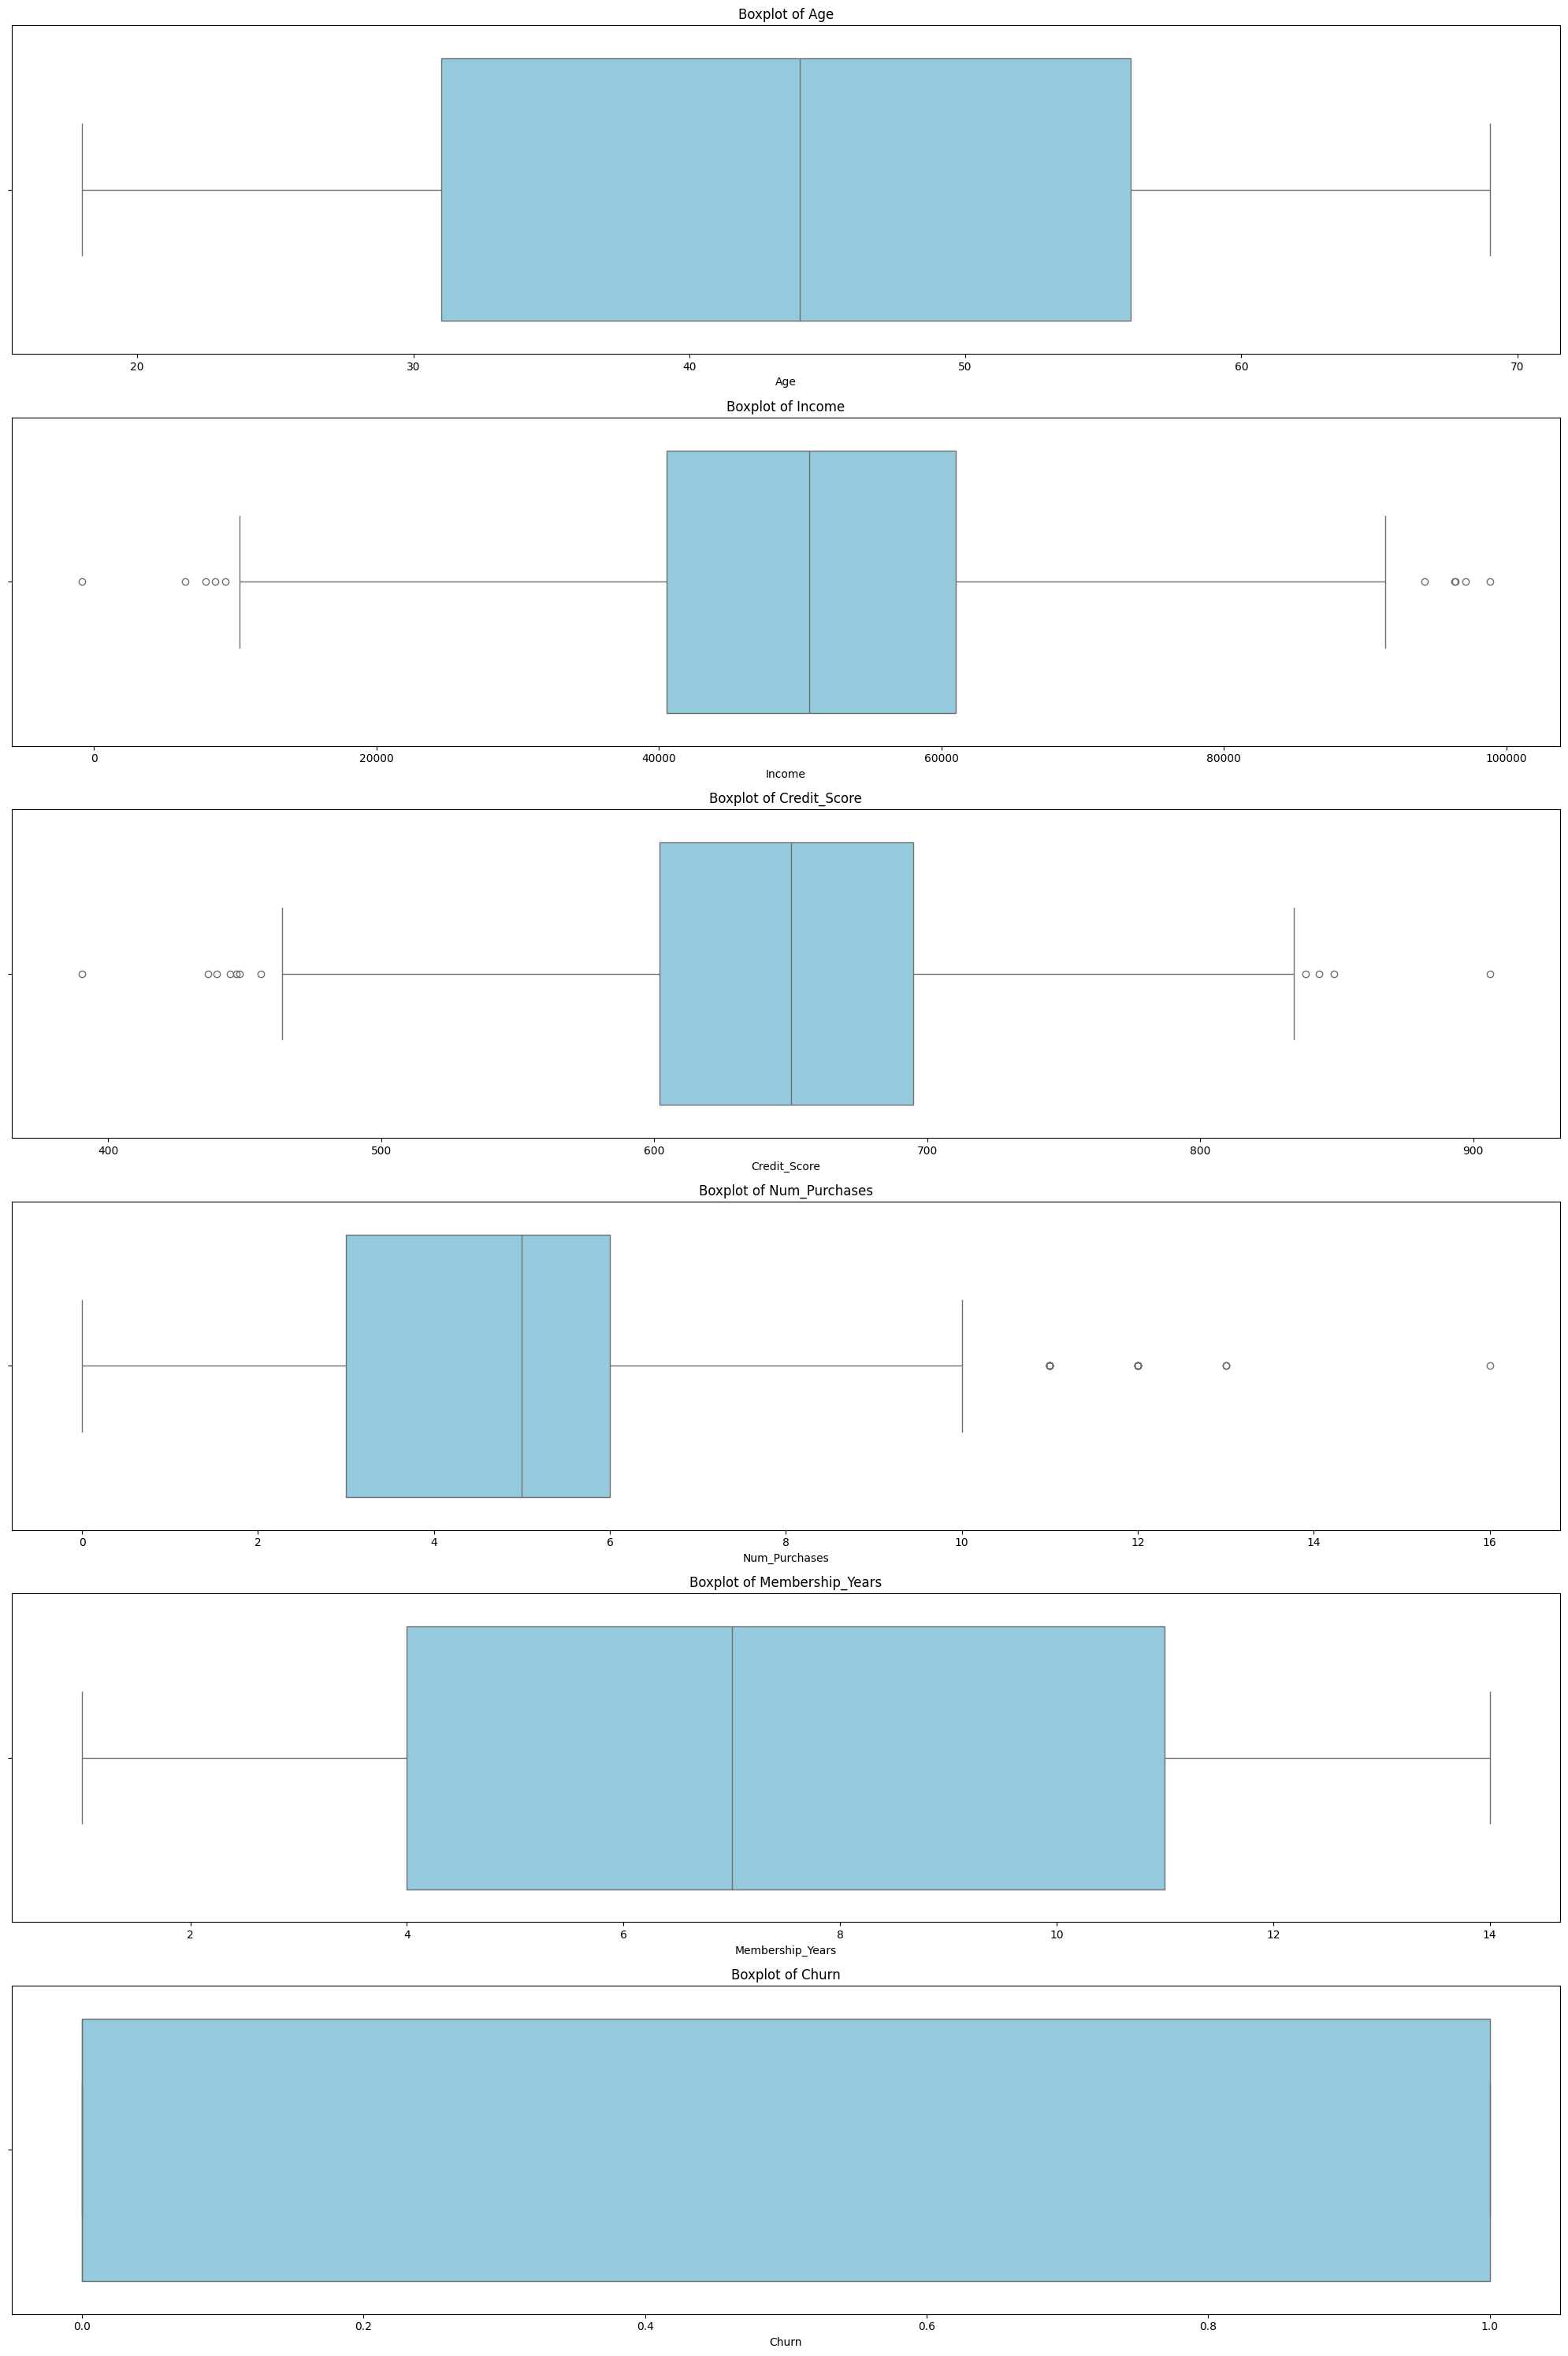

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for boxplot analysis
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Set up the figure
plt.figure(figsize=(20, 30))

# Plot boxplots for each numerical feature including the target variable 'OUTCOME'
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.tight_layout()

plt.show()


## Number of Unique values in each features

### Numerical Features

In [115]:
numerical_data.nunique()

,0
Age,52
Income,1425
Credit_Score,1425
Num_Purchases,15
Membership_Years,14
Churn,2


### Missing Values

In [116]:
numerical_data.isna().sum()

,0
Age,75
Income,75
Credit_Score,75
Num_Purchases,0
Membership_Years,0
Churn,0


### Categorical Features

In [117]:
categorical_data.nunique()

,0
Gender,3
Marital_Status,3
Device_Used,3


# Barplot of unique value counts in every categorical features

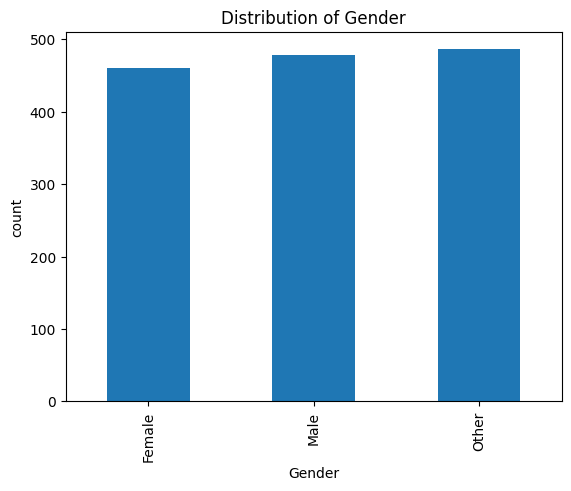

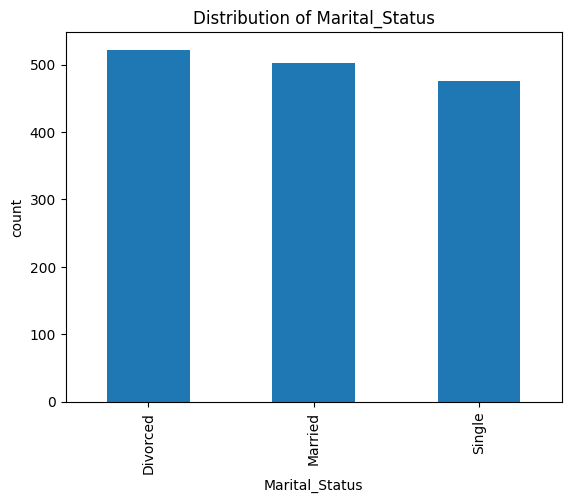

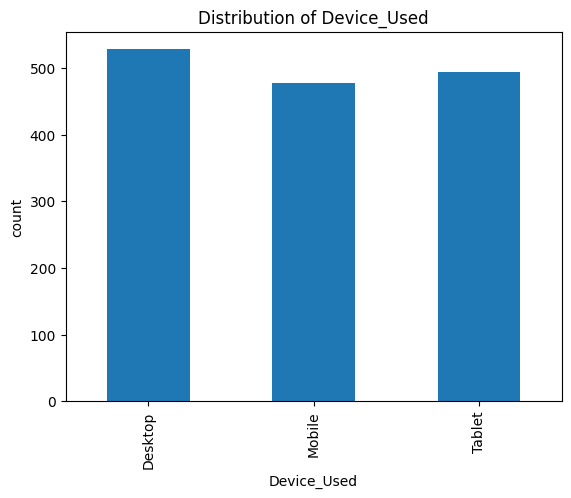

In [118]:
for col in categorical_features:
    plt.title(f'Distribution of {col}')
    categorical_data[col].value_counts().sort_index().plot(kind='bar', xlabel=col,ylabel='count')
    plt.show()

# Correlation Analysis
## Correlation matrix of whole dataset

In [119]:
# Calculate the correlation matrix
correlation_matrix = numerical_data.corr()
correlation_matrix

,Age,Income,Credit_Score,Num_Purchases,Membership_Years,Churn
Age,1.000000,0.015700,-0.010746,0.025846,-0.019024,0.006202
Income,0.015700,1.000000,0.013684,-0.009576,0.009499,0.026626
Credit_Score,-0.010746,0.013684,1.000000,0.000861,0.011292,0.019973
Num_Purchases,0.025846,-0.009576,0.000861,1.000000,0.032381,-0.032126
Membership_Years,-0.019024,0.009499,0.011292,0.032381,1.000000,0.001416
Churn,0.006202,0.026626,0.019973,-0.032126,0.001416,1.000000


### **Correlation Heatmap plot of whole dataset**

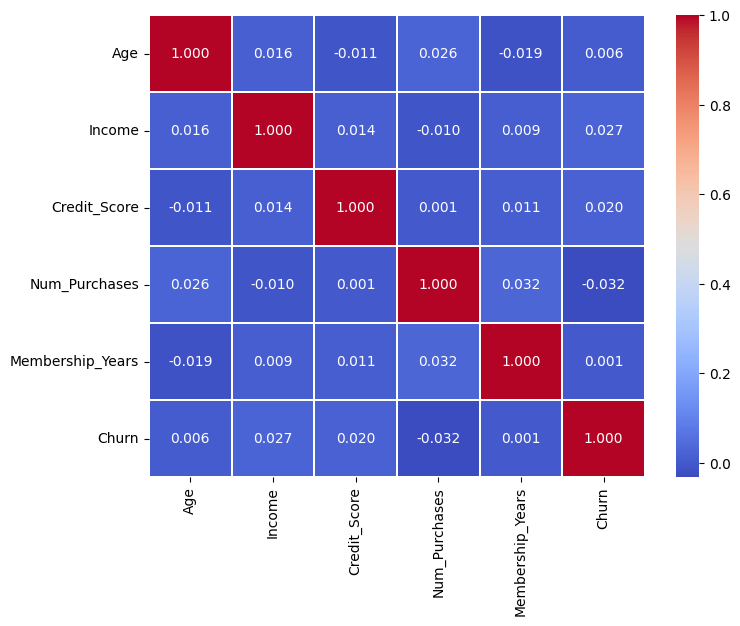

In [120]:
# Plotting the heatmap for correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.3)
plt.show()

### **Data visualization**
#### Some other visualizations of features to get more insights

### **Density plots of numerical features**

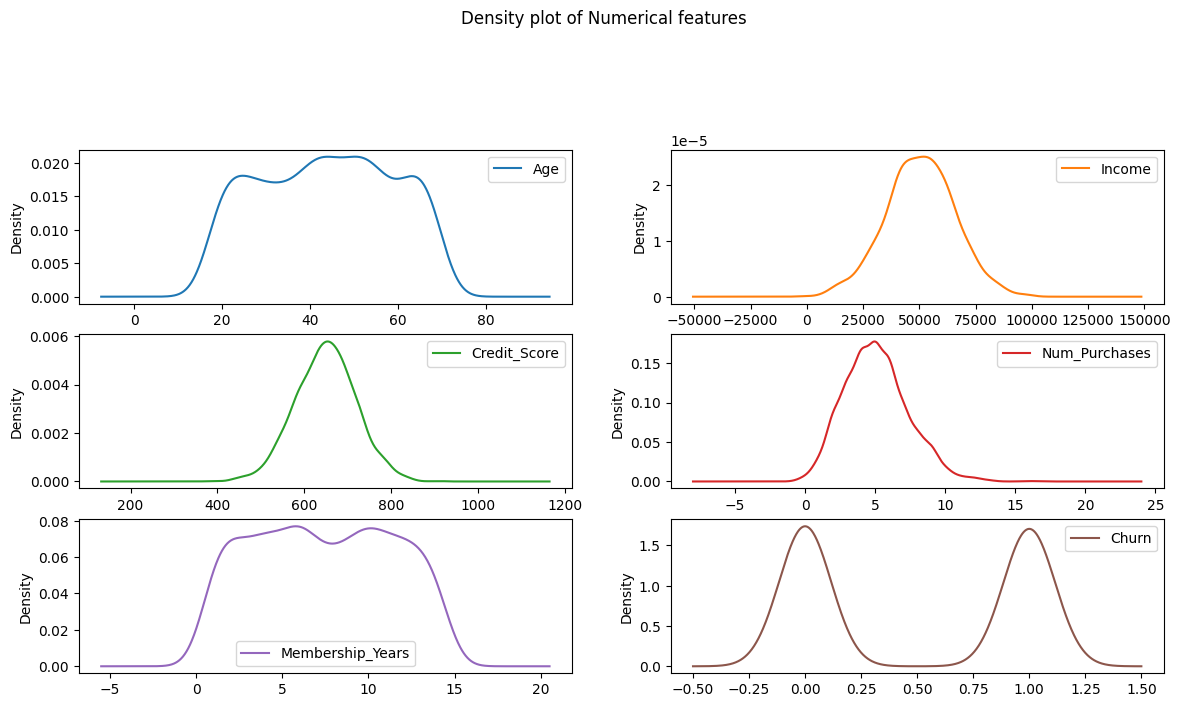

In [121]:
numerical_data.plot(kind='density',figsize=(14,14),subplots=True,layout=(6,2),title="Density plot of Numerical features",sharex=False)
plt.show()

### **SUMMARY**

We have performed a comprehensive **Exploratory Data Analysis (EDA)** focused on customer behavior and demographic profiling. The analysis begins with **Descriptive Statistics** to understand the central tendency and dispersion of numerical features such as age, income, and credit scores. A key component of the study is **Skewness Interpretation**, which reveals that most numerical variables—including Age, Income, Credit_Score, and Membership_Years—follow a nearly normal or symmetrical distribution, suggesting a well-balanced dataset. The only exception is the number of purchases, which exhibits a **moderate right-skew**, indicating that while most customers make few purchases, a small segment is highly active. Additionally, the categorical analysis identifies significant patterns, such as "Desktop" being the primary device used and "Divorced" being the most frequent marital status among the sampled population. Finally, the data quality assessment highlights that the dataset contains **75 missing values** across several critical features, marking an important step for subsequent data cleaning and modeling.

# Dataset Pre-Processing

In [122]:
numerical_data.isna().sum()

,0
Age,75
Income,75
Credit_Score,75
Num_Purchases,0
Membership_Years,0
Churn,0


In [123]:
categorical_data.isna().sum()

,0
Gender,75
Marital_Status,0
Device_Used,0


## Handling Anomalies
### **Observation**:
During the Exploratory Data Analysis (EDA), the boxplots revealed specific data points that defy logical constraints or domain standards.

### **Income**:
The boxplot for Income showed a data point with a negative value (-826.42). Since income cannot be negative, this is identified as an error.

### **Credit Score**:
The boxplot for Credit_Score highlighted a value exceeding 850 (specifically 906), which is outside the standard range for credit scores.

### **Action**:
To ensure the quality of the dataset for modeling, we filtered out these specific anomalous rows.

In [124]:
df[df['Income']  < 0]

,Age,Income,Gender,Marital_Status,Credit_Score,Num_Purchases,Membership_Years,Device_Used,Churn
593,24.0,-826.42124,Female,Divorced,542.911696,5,11,Tablet,1


In [125]:
df[df['Credit_Score'] > 850]

,Age,Income,Gender,Marital_Status,Credit_Score,Num_Purchases,Membership_Years,Device_Used,Churn
119,56.0,45026.200636,Female,Single,906.039126,7,10,Mobile,0


In [126]:
df = df[(df['Income'] >= 0) | (df['Income'].isna())]
df = df[(df['Credit_Score'] <= 850) | (df['Credit_Score'].isna())]

In [127]:
df

,Age,Income,Gender,Marital_Status,Credit_Score,Num_Purchases,Membership_Years,Device_Used,Churn
0,56.0,70201.189680,Female,Married,687.761776,9,12,Desktop,0
1,69.0,51901.897395,Male,Single,712.617115,3,14,Tablet,0
2,46.0,38605.409293,Male,Married,782.299643,5,8,Mobile,0
3,32.0,49949.736955,Female,Single,697.749518,7,1,Tablet,0
4,NaN,48965.290095,Other,Married,663.155216,4,4,Desktop,1
...,...,...,...,...,...,...,...,...,...
1495,40.0,38575.311408,Male,Single,717.997517,3,9,Mobile,0
1496,54.0,47273.370862,Other,Single,678.621530,4,2,Desktop,1
1497,28.0,52600.121356,Other,Divorced,611.316046,2,3,Desktop,0
1498,23.0,63187.644522,Female,Divorced,690.256745,5,7,Tablet,1


# Simple Imputer
We used Simple Imputer to handle missing data in our dataset. This technique replaces null values with a statistical estimate derived from the available data.

In [128]:
from sklearn.impute import SimpleImputer

# For numerical data, we use the 'median' strategy
num_imputer = SimpleImputer(strategy='median')

# For categorical data, we use the 'mode' strategy
cat_imputer = SimpleImputer(strategy='most_frequent')

# Fill Age, Income, Credit_Score
num_cols = ['Age', 'Income', 'Credit_Score']
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Fill Gender
df[['Gender']] = cat_imputer.fit_transform(df[['Gender']])

In [129]:
df.isna().sum()

,0
Age,0
Income,0
Gender,0
Marital_Status,0
Credit_Score,0
Num_Purchases,0
Membership_Years,0
Device_Used,0
Churn,0


# One hot encoding

We used One-Hot Encoding because our categorical variables (Gender, Marital Status, Device) have no inherent order, and this method converts them into a numerical format.

In [130]:
categorical_cols = ['Gender', 'Marital_Status', 'Device_Used']

# drop_first=True removes the first category to prevent redundancy
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [131]:
df_encoded.head()

,Age,Income,Credit_Score,Num_Purchases,Membership_Years,Churn,Gender_Male,Gender_Other,Marital_Status_Married,Marital_Status_Single,Device_Used_Mobile,Device_Used_Tablet
0,56.0,70201.189680,687.761776,9,12,0,False,False,True,False,False,False
1,69.0,51901.897395,712.617115,3,14,0,True,False,False,True,False,True
2,46.0,38605.409293,782.299643,5,8,0,True,False,True,False,True,False
3,32.0,49949.736955,697.749518,7,1,0,False,False,False,True,False,True
4,44.0,48965.290095,663.155216,4,4,1,False,True,True,False,False,False


# Splitting

We are splitting the whole dataset with 80% data for training and 20% data for testing so that we can avoid data leakage.

In [132]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# random_state here works like np.random_seed(42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the shapes to be sure
print("Training Data:", X_train.shape)
print("Test Data:", X_test.shape)

Training Data: (1198, 11)
Test Data: (300, 11)


# Standard Scaler

We applied Standard Scaler to normalize the numerical features (like Income and Age) to a common scale.

In [133]:
scaler = StandardScaler()

# Select numerical columns to scale
cols_to_scale = ['Age', 'Income', 'Credit_Score', 'Num_Purchases', 'Membership_Years']

# "transform" actually changes the numbers
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# We use .transform() here, NOT .fit_transform()
# This uses the Mean/Std Dev from the training set to scale the Test set
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])


X_train.head()

,Age,Income,Credit_Score,Num_Purchases,Membership_Years,Gender_Male,Gender_Other,Marital_Status_Married,Marital_Status_Single,Device_Used_Mobile,Device_Used_Tablet
1162,1.211717,0.520973,0.378703,-0.035436,1.159666,True,False,True,False,False,False
1274,-1.515515,-0.786236,0.010603,0.411425,0.908848,False,False,False,True,False,False
1113,-1.174611,-0.188495,1.384684,-1.376017,0.658030,False,False,True,False,False,False
434,-1.310972,-1.648205,1.294281,-1.822878,0.156395,False,True,False,False,False,True
1081,-1.310972,-1.223382,-0.074071,-0.929157,-0.345241,True,False,False,False,False,False


# Model Training

We have to use a total of 4 models to our dataset. We are using:

<ol>
  <li>Logistic Regression</li>
  <li>Random Forest Classifier</li>
  <li>Multi-Layer Perceptron</li>
  <li>K-Means Clustering</li>
</ol>

## 1. Logistic Regression

In [134]:
from sklearn.linear_model import LogisticRegression

# Model
log_reg = LogisticRegression(max_iter=5000, random_state=42)

# Train
log_reg.fit(X_train, y_train)

# Predict
y_pred_log = log_reg.predict(X_test)

# print(np.mean(y_pred_log == y_test))

## 2. Random Forest Classifier

In [135]:
from sklearn.ensemble import RandomForestClassifier

# Model
rf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)

# Train
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# np.mean(y_pred_rf == y_test)

## 3. Multi Layer Perceptron

In [136]:
from sklearn.neural_network import MLPClassifier

# Model
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), activation="relu", solver="sgd", learning_rate_init=1e-3, max_iter=500, early_stopping=True, random_state=42)

# Train
mlp.fit(X_train, y_train)

# Predict
y_pred_mlp = mlp.predict(X_test)

# np.mean(y_pred_mlp == y_test)

## 4. K-means Clustering

In [137]:
from sklearn.cluster import KMeans

# Model
kmeans = KMeans(n_clusters=2, random_state=42)

# Train
kmeans.fit(X_train)

# Predict
y_pred_kmeans = kmeans.predict(X_test)

# np.mean(y_pred_kmeans == y_test)

# Model Evaluation

The model evaluation here fulfills these requirements:

* Bar chart showcasing prediction accuracy and f1 score of all models
* Confusion Matrix
* Performance metrics comparison of each model
* AUC score, ROC curve


## 1. Logistic Regression

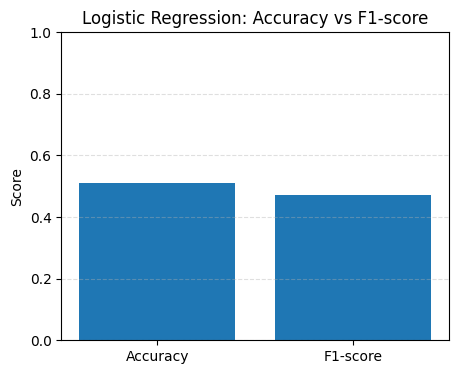

In [138]:
acc_log = accuracy_score(y_test, y_pred_log)
f1_log  = f1_score(y_test, y_pred_log)

# Bar chart
plt.figure(figsize=(5, 4))
plt.bar(["Accuracy", "F1-score"], [acc_log, f1_log])
plt.ylim(0, 1)
plt.title("Logistic Regression: Accuracy vs F1-score")
plt.ylabel("Score")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()


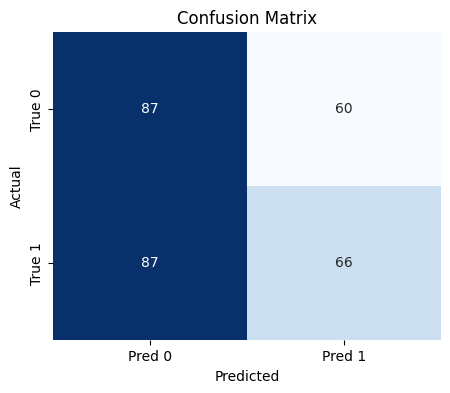

In [139]:
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 2. Random Forest Classifier

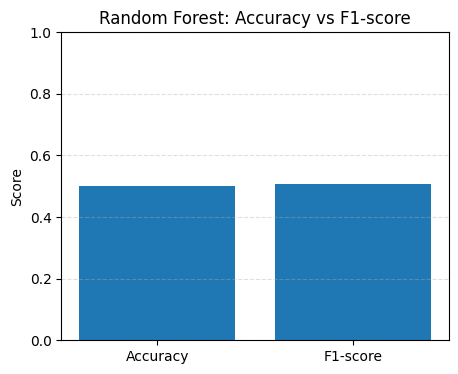

In [140]:
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf  = f1_score(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))
plt.bar(["Accuracy", "F1-score"], [acc_rf, f1_rf])
plt.ylim(0, 1)
plt.title("Random Forest: Accuracy vs F1-score")
plt.ylabel("Score")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()


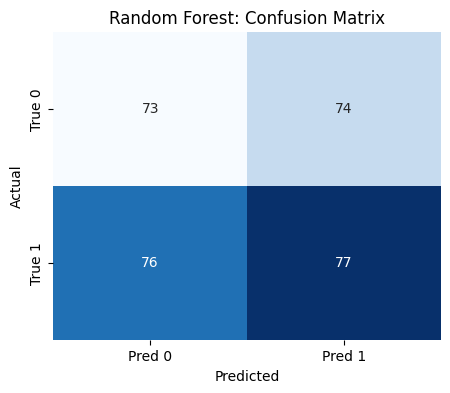

In [141]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
plt.title("Random Forest: Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## 3. Multi Layer Perceptron

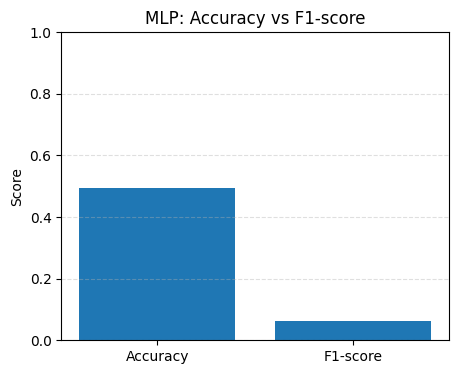

In [142]:
acc_mlp = accuracy_score(y_test, y_pred_mlp)
f1_mlp  = f1_score(y_test, y_pred_mlp)

plt.figure(figsize=(5, 4))
plt.bar(["Accuracy", "F1-score"], [acc_mlp, f1_mlp])
plt.ylim(0, 1)
plt.title("MLP: Accuracy vs F1-score")
plt.ylabel("Score")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()


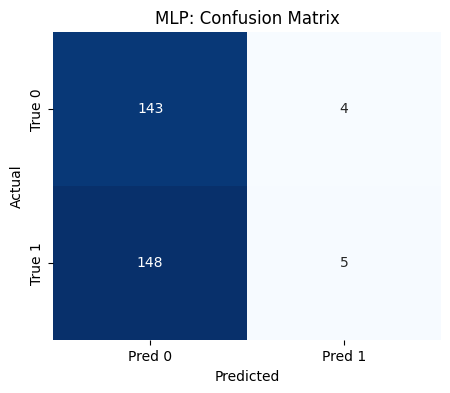

In [143]:
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_mlp, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
plt.title("MLP: Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## 4. K-Means Clustering

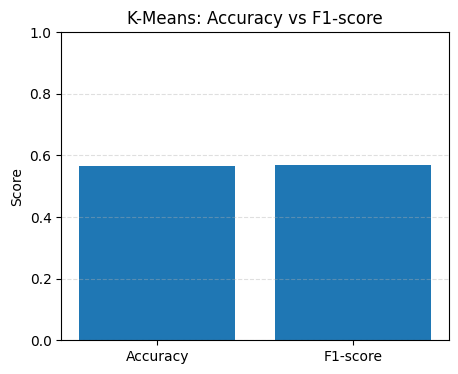

In [144]:
acc_kmeans = accuracy_score(y_test, y_pred_kmeans)
f1_kmeans  = f1_score(y_test, y_pred_kmeans)

plt.figure(figsize=(5,4))
plt.bar(["Accuracy", "F1-score"], [acc_kmeans, f1_kmeans])
plt.ylim(0, 1)
plt.title("K-Means: Accuracy vs F1-score")
plt.ylabel("Score")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()


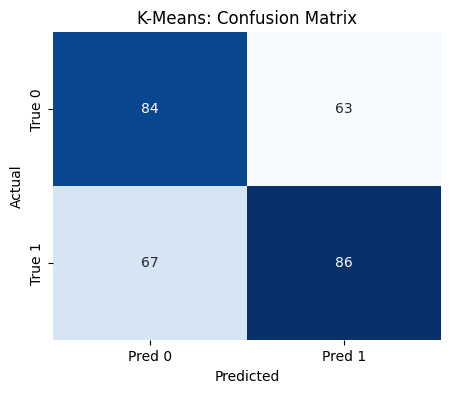

In [145]:
cm_kmeans = confusion_matrix(y_test, y_pred_kmeans)

plt.figure(figsize=(5,4))
sns.heatmap(cm_kmeans, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
plt.title("K-Means: Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


### PCA is used to reduce dimensions (many features → 2 components) for visualization.

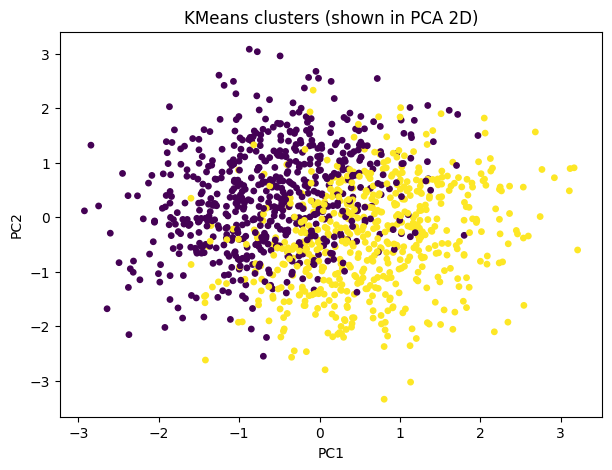

In [146]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA projection for visualization (fit PCA on training only)
pca = PCA(n_components=2, random_state=42)
X_train_2d = pca.fit_transform(X_train)
X_test_2d  = pca.transform(X_test)

# Using existing KMeans labels
train_labels = kmeans.labels_
test_labels  = y_pred_kmeans

# Plot
plt.figure(figsize=(7,5))
plt.scatter(X_train_2d[:,0], X_train_2d[:,1], c=train_labels, s=15, cmap="viridis")
plt.title("KMeans clusters (shown in PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


### Performance metrics comparison of each model

In [147]:
models = {
    "Logistic Regression": y_pred_log,
    "Random Forest": y_pred_rf,
    "MLP": y_pred_mlp,
    "K-Means": y_pred_kmeans
}

rows = []
for name, y_pred in models.items():
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
    })

metrics_df = pd.DataFrame(rows).sort_values("F1-score", ascending=False).reset_index(drop=True)
metrics_df


,Model,Accuracy,Precision,Recall,F1-score
0,K-Means,0.566667,0.577181,0.562092,0.569536
1,Random Forest,0.500000,0.509934,0.503268,0.506579
2,Logistic Regression,0.510000,0.523810,0.431373,0.473118
3,MLP,0.493333,0.555556,0.032680,0.061728


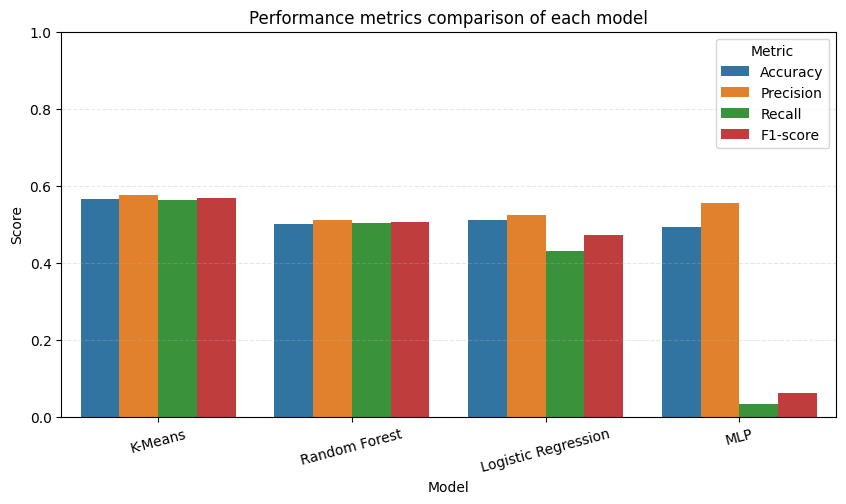

In [148]:
melted = metrics_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(10,5))
sns.barplot(data=melted, x="Model", y="Score", hue="Metric")
plt.ylim(0, 1)
plt.title("Performance metrics comparison of each model")
plt.xticks(rotation=15)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.show()


## AUC and ROC

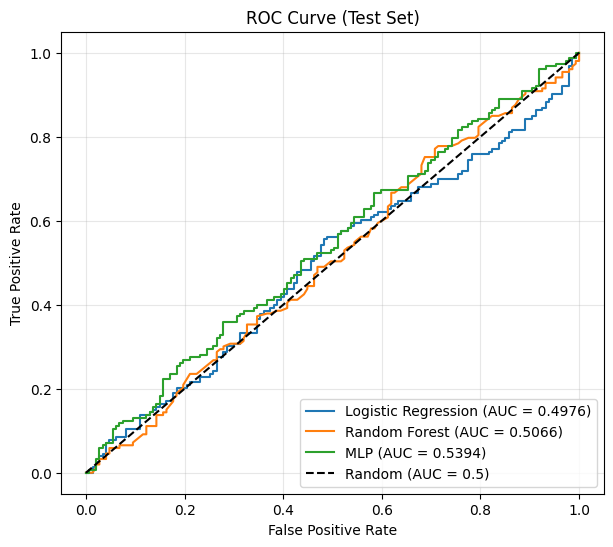

In [149]:
from sklearn.metrics import roc_curve, roc_auc_score

models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf,
    "MLP": mlp
}

plt.figure(figsize=(7,6))

for name, model in models.items():
    y_score = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_score)
    fpr, tpr, _ = roc_curve(y_test, y_score)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")



plt.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.5)")
plt.title("ROC Curve (Test Set)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()
